In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.feature_selection import SelectKBest, f_regression
from sklearn.metrics import mean_absolute_error, r2_score


In [3]:
pd.set_option('display.max_rows',None)
pd.set_option('display.max_columns',None)

In [4]:
df1  = pd.read_excel("C:/Users/DEEL/OneDrive/Desktop/Dealio/snapdeal.xlsx")

In [5]:
df2 = pd.read_csv("C:/Users/DEEL/OneDrive/Desktop/Dealio/amazon_product_details.csv")

In [6]:
df2.head()

,Title,Actual_Price,Selling_Price,Brand,Model,Colour,Form_Factor,Connectivity_Type
0,Dylect in-Ear Wired Earphone I Stereo Quality ...,299.0,188.0,Dylect,Dylect Wired Earphone,Black,In Ear,Wired
1,"Jabra Engage 65 Wireless Headset, Mono – Telep...",77914.0,57914.0,Jabra,Engage 65 Mono,Black,On Ear,Wireless
2,Jabra Elite 3 in Ear Bluetooth Truly Wireless ...,6999.0,4499.0,Jabra,Elite 3,Dark Grey,NaN,NaN
3,Zebronics Zeb-Sound Bomb 3 TWS In Ear Earbuds ...,3499.0,799.0,ZEBRONICS,Zeb - Sound Bomb 3 (Blue),Blue,In Ear,Wireless
4,(Renewed) boAt Airdopes 402 Bluetooth Truly Wi...,NaN,NaN,boAt,Boat Airdopes 408,Black,In Ear,Wireless


In [7]:
df2.shape

(1406, 8)

In [8]:
df2.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1406 entries, 0 to 1405
Data columns (total 8 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Title              1406 non-null   object 
 1   Actual_Price       1085 non-null   float64
 2   Selling_Price      1185 non-null   float64
 3   Brand              1406 non-null   object 
 4   Model              1027 non-null   object 
 5   Colour             1381 non-null   object 
 6   Form_Factor        1263 non-null   object 
 7   Connectivity_Type  1290 non-null   object 
dtypes: float64(2), object(6)
memory usage: 88.0+ KB


In [21]:
df2.describe()

,Actual_Price,Selling_Price
count,1085.000000,1185.000000
mean,6703.301696,3848.234599
std,12398.108429,8950.061845
min,299.000000,89.000000
25%,1290.000000,499.000000
50%,2999.000000,1125.000000
75%,4999.000000,2129.000000
max,118122.000000,80652.000000


In [22]:
df2.duplicated().sum()

216

In [23]:
df2.isnull().sum()

Title                  0
Actual_Price         321
Selling_Price        221
Brand                  0
Model                379
Colour                25
Form_Factor          143
Connectivity_Type    116
dtype: int64

In [24]:
df3 = pd.read_csv("C:/Users/DEEL/OneDrive/Desktop/Dealio/flipkart.csv")

In [25]:
df3.head()

,Unnamed: 0,company,name,color,type,ratings,people_review,offer_price,real_price,offer
0,0,Aroma,NB119B Badshah - 40 Hours Playtime Bluetooth N...,Black,In the Ear,4.0,"2,40,115",₹381,"₹1,499",74% off
1,1,TECHFIRE,Fire 500v2 Neckband hi-bass Wireless Bluetooth...,Blue,In the Ear,3.9,"1,88,519",₹445,"₹3,850",88% off
2,2,Aroma,NB119 Titanium - 48 Hours Playtime Bluetooth N...,Blue,In the Ear,4.0,"1,62,560",₹499,"₹2,499",80% off
3,3,Boult,"Audio Z40 with Zen ENC Mic, 60H Battery Life, ...",White,In the Ear,4.2,"14,276","₹1,299","₹4,999",74% off
4,4,Aroma,NB119Pro Belief 48 Hours Playing Time Fast Cha...,Blue,In the Ear,4.0,"65,327",₹395,"₹1,999",80% off


In [26]:
df3.shape

(948, 10)

In [27]:
df3.describe()

,Unnamed: 0,ratings
count,948.000000,948.000000
mean,473.500000,3.904008
std,273.808327,0.275284
min,0.000000,2.000000
25%,236.750000,3.700000
50%,473.500000,3.900000
75%,710.250000,4.100000
max,947.000000,5.000000


In [28]:
df3.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 948 entries, 0 to 947
Data columns (total 10 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Unnamed: 0     948 non-null    int64  
 1   company        948 non-null    object 
 2   name           948 non-null    object 
 3   color          948 non-null    object 
 4   type           948 non-null    object 
 5   ratings        948 non-null    float64
 6   people_review  948 non-null    object 
 7   offer_price    948 non-null    object 
 8   real_price     948 non-null    object 
 9   offer          948 non-null    object 
dtypes: float64(1), int64(1), object(8)
memory usage: 74.2+ KB


In [29]:
df3['offer_price'] = df3['offer_price'].str.replace(r'[^\d.]', '', regex=True)
df3['real_price'] = df3['real_price'].str.replace(r'[^\d.]', '', regex=True)

In [30]:
df3['offer_price'] = pd.to_numeric(df3['offer_price'], errors='coerce')
df3['real_price'] = pd.to_numeric(df3['real_price'], errors='coerce')

In [31]:
df3.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 948 entries, 0 to 947
Data columns (total 10 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Unnamed: 0     948 non-null    int64  
 1   company        948 non-null    object 
 2   name           948 non-null    object 
 3   color          948 non-null    object 
 4   type           948 non-null    object 
 5   ratings        948 non-null    float64
 6   people_review  948 non-null    object 
 7   offer_price    948 non-null    int64  
 8   real_price     948 non-null    int64  
 9   offer          948 non-null    object 
dtypes: float64(1), int64(3), object(6)
memory usage: 74.2+ KB


In [32]:
df3['company'].value_counts()

company
Boult           146
Aroma           127
boAt             60
Mivi             48
TECHFIRE         44
truke            23
U&i              22
PTron            17
Ucool            16
Wings            15
Noise            15
realme           14
HOPPUP           12
Portronics       12
OPPO             10
OnePlus           9
Ubon              9
ORAIMO            8
snowbudy          8
Tunifi            7
DEFY              7
ROKAVO            7
FUR               6
Lichen            6
KDM               6
DigiClues         6
CARRON            6
GAGANDEEP         6
UPOZA             6
FPX               6
IZWI              5
SONY              5
flying            5
Syska             5
Digiwins          5
GREE              5
Earboss           5
KRAZZY            5
CIHLEX            5
blue              5
JBL               4
D1Y3              4
Fire-Boltt        4
Kabeer            4
Dozokil           4
Fome              4
Nexbird           4
SYARA             4
divinestar        4
Alfanso     

In [33]:
df3['company'].value_counts().shape

(173,)

<Axes: xlabel='company'>

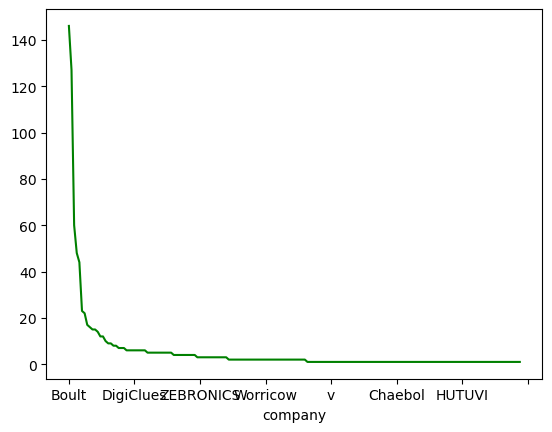

In [34]:
df3['company'].value_counts().plot(kind='line',color='green')

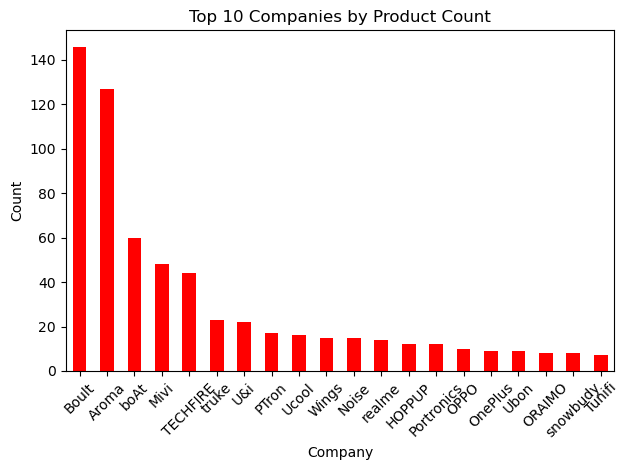

In [35]:

top_companies = df3['company'].value_counts().head(20)

plt.figure()
top_companies.plot(kind='bar', color='red')

plt.xticks(rotation=45)
plt.title("Top 10 Companies by Product Count")
plt.xlabel("Company")
plt.ylabel("Count")
plt.tight_layout()
plt.show()

In [36]:
df3['name'].value_counts()

name
Audio Z40 with Zen ENC Mic, 60H Battery Life, Low...        31
NB140 Evolve 24 Hours* Playtime | Deep Bass | Mad...        29
NB140 Captain 24 Hours* Playtime | Deep Bass | Ma...        21
Audio Truebuds with 30H Battery, IPX7 Waterproof,...        21
Audio AirBass Y1 TWS Earbuds, 40H Playtime, Fast ...        20
Audio YCharge with Pro+ Calling Mic, Full Charge ...        19
Airdopes 161 with ASAP Charge, 10mm Drivers and 17...       13
Fire 500v2 Neckband hi-bass Wireless Bluetooth...           12
DuoPods K5 TWS Earbuds Metallic Finish, HD calling...       12
Audio ProBass EQCharge with ZEN Mode ENC, 32hrs P...        12
Bassbuds Joy TWS with 13mm Drivers, Stereo Calls,...        11
Audio Gearpods with 32H Playtime, Fast Charging, ...        10
NB137 Nexon 16 Hours* Playtime Deep Bass True Wir...         9
Airdopes 131 with upto 60 Hours and ASAP Charge Bl...        8
Rockerz 235 Pro with upto 20 Hours Playback & ASAP...        8
Fire 500v2 Neckband hi-bass Wireless headphone... 

In [37]:
df3.sample(10)

,Unnamed: 0,company,name,color,type,ratings,people_review,offer_price,real_price,offer
315,315,Boult,Audio Curve ANC with Active Noice Cancellation...,Black,In the Ear,3.7,"2,493",1499,5499,72% off
358,358,Boltune,BT-335 Neckband hi-bass Wireless Bluetooth hea...,Black,In the Ear,3.8,"19,277",449,3850,88% off
825,825,CIHLEX,C-54 Super Bass Bluetooth Earphones Neckband H...,Green,In the Ear,3.6,30,749,1999,62% off
662,662,Aroma,NB140 Captain 24 Hours* Playtime | Deep Bass |...,Dark Blue,True Wireless,3.7,"8,896",546,1999,72% off
12,12,boAt,Airdopes 131 with upto 60 Hours and ASAP Charg...,Active Black Matte Indi,True Wireless,4.0,"13,45,614",899,2990,69% off
707,707,Xezbi,Earbuds M10 Air-Pro Wireless Earphone Touch Co...,Black,True Wireless,3.9,"1,88,519",549,3899,85% off
272,272,Aroma,NB119 Jersey - 48 Hours Playtime Fast Charging...,Red,In the Ear,4.1,"17,364",399,2499,84% off
845,845,GUGGU,OGW_462T HSB-730 Bluetooth for all Smartphones...,Black,In the Ear,3.8,705,349,999,65% off
117,117,truke,"BTG Alpha Earbuds with Game Mode, 38H Playtime...",Black,True Wireless,3.9,"16,564",699,2499,72% off
554,554,CIHROX,"Bluetooth Neckband 12Hrs Playback, 10mm Driver...",Black,In the Ear,4.0,"49,704",499,1899,73% off


In [38]:
df3['name'].isnull().sum()

0

In [39]:
df3['name'].value_counts()

name
Audio Z40 with Zen ENC Mic, 60H Battery Life, Low...        31
NB140 Evolve 24 Hours* Playtime | Deep Bass | Mad...        29
NB140 Captain 24 Hours* Playtime | Deep Bass | Ma...        21
Audio Truebuds with 30H Battery, IPX7 Waterproof,...        21
Audio AirBass Y1 TWS Earbuds, 40H Playtime, Fast ...        20
Audio YCharge with Pro+ Calling Mic, Full Charge ...        19
Airdopes 161 with ASAP Charge, 10mm Drivers and 17...       13
Fire 500v2 Neckband hi-bass Wireless Bluetooth...           12
DuoPods K5 TWS Earbuds Metallic Finish, HD calling...       12
Audio ProBass EQCharge with ZEN Mode ENC, 32hrs P...        12
Bassbuds Joy TWS with 13mm Drivers, Stereo Calls,...        11
Audio Gearpods with 32H Playtime, Fast Charging, ...        10
NB137 Nexon 16 Hours* Playtime Deep Bass True Wir...         9
Airdopes 131 with upto 60 Hours and ASAP Charge Bl...        8
Rockerz 235 Pro with upto 20 Hours Playback & ASAP...        8
Fire 500v2 Neckband hi-bass Wireless headphone... 

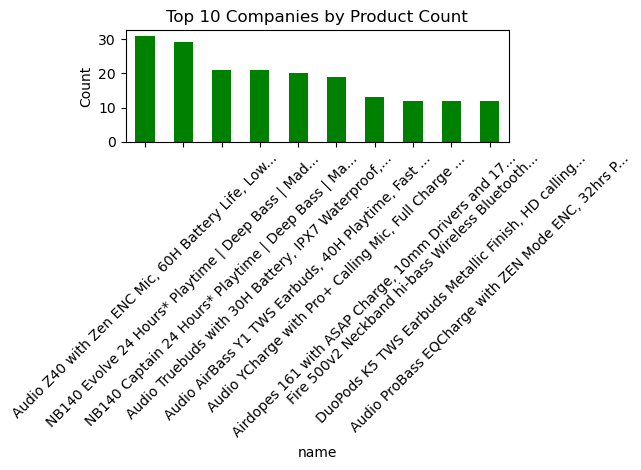

In [40]:
top_companies = df3['name'].value_counts().head(10)

plt.figure()
top_companies.plot(kind='bar', color='green')

plt.xticks(rotation=45)
plt.title("Top 10 Companies by Product Count")
plt.xlabel("name")
plt.ylabel("Count")
plt.tight_layout()
plt.show()

In [41]:
df3['name'].sample(10)

569    Necklace 4 Fast Charge, 50hr PlayTime, Super B...
741    Tech M19 / M90 / M10 / T2TWS Bluetooth 5.0 Wir...
649    Wireless Neckband CL-50 with Longlasting 30H P...
576    Silver neckband wireless headphone headset ear...
662    NB140 Captain 24 Hours* Playtime | Deep Bass |...
685    F-255 neckband bluetooth headphone with Fast C...
82     NB119D Dream 60 Hours Playing Time Fast Chargi...
625    BassFit Pro (30 hours Backup) Wireless Neckban...
462    NB119 Neutron 60 Hours PlayTime With 4 EQ mode...
607    F-700 40 Hours Playtime Bluetooth Wireless Nec...
Name: name, dtype: object

In [42]:
df3['battery_hours'] = df3['name'].str.extract(r'(\d+)\s*(?:Hours?|Hrs?|H)')[0]

In [43]:
df3['fast_charging'] = df3['name'].str.contains('Fast', case=False)

In [44]:
df3['ENC'] = df3['name'].str.contains('ENC', case=False)
df3['ANC'] = df3['name'].str.contains('ANC', case=False)

In [45]:
df3['bluetooth_version'] = df3['name'].str.extract(r'Bluetooth\s*([\d.]+)')

In [46]:
df3['waterproof_rating'] = df3['name'].str.extract(r'(IPX\d)')

In [47]:
df3.columns

Index(['Unnamed: 0', 'company', 'name', 'color', 'type', 'ratings',
       'people_review', 'offer_price', 'real_price', 'offer', 'battery_hours',
       'fast_charging', 'ENC', 'ANC', 'bluetooth_version',
       'waterproof_rating'],
      dtype='object')

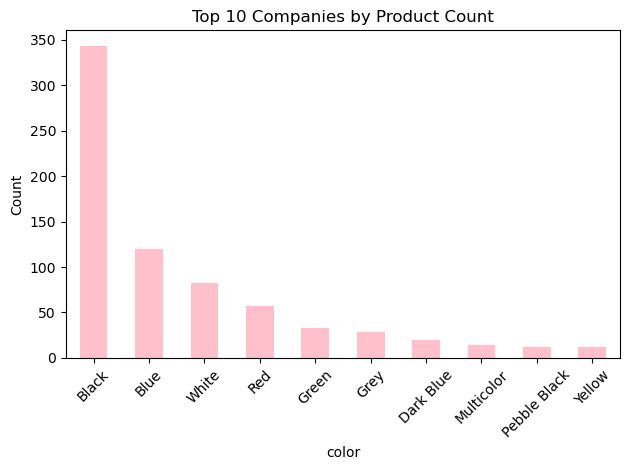

In [48]:
top_companies = df3['color'].value_counts().head(10)

plt.figure()
top_companies.plot(kind='bar', color='pink')

plt.xticks(rotation=45)
plt.title("Top 10 Companies by Product Count")
plt.xlabel("color")
plt.ylabel("Count")
plt.tight_layout()
plt.show()

In [49]:
df3['color'].value_counts()

color
Black                                                       343
Blue                                                        120
White                                                        82
Red                                                          57
Green                                                        33
Grey                                                         29
Dark Blue                                                    20
Multicolor                                                   14
Pebble Black                                                 12
Yellow                                                       12
White  Silver                                                 9
Cobalt Blue                                                   9
Navy Blue                                                     7
Black  Silver                                                 7
Silver                                                        6
Active Black                      

In [50]:
df3.isnull().sum()

Unnamed: 0             0
company                0
name                   0
color                  0
type                   0
ratings                0
people_review          0
offer_price            0
real_price             0
offer                  0
battery_hours        455
fast_charging          0
ENC                    0
ANC                    0
bluetooth_version    903
waterproof_rating    921
dtype: int64

In [51]:
df3

,Unnamed: 0,company,name,color,type,ratings,people_review,offer_price,real_price,offer,battery_hours,fast_charging,ENC,ANC,bluetooth_version,waterproof_rating
0,0,Aroma,NB119B Badshah - 40 Hours Playtime Bluetooth N...,Black,In the Ear,4.0,"2,40,115",381,1499,74% off,40,False,False,False,NaN,NaN
1,1,TECHFIRE,Fire 500v2 Neckband hi-bass Wireless Bluetooth...,Blue,In the Ear,3.9,"1,88,519",445,3850,88% off,NaN,False,False,False,...,NaN
2,2,Aroma,NB119 Titanium - 48 Hours Playtime Bluetooth N...,Blue,In the Ear,4.0,"1,62,560",499,2499,80% off,48,False,False,False,NaN,NaN
3,3,Boult,"Audio Z40 with Zen ENC Mic, 60H Battery Life, ...",White,In the Ear,4.2,"14,276",1299,4999,74% off,60,False,True,False,NaN,NaN
4,4,Aroma,NB119Pro Belief 48 Hours Playing Time Fast Cha...,Blue,In the Ear,4.0,"65,327",395,1999,80% off,48,True,False,False,NaN,NaN
5,5,Aroma,NB119 Titanium - 48 Hours Playtime Bluetooth N...,Black,In the Ear,4.0,"1,62,560",499,2499,80% off,48,False,False,False,NaN,NaN
6,6,OnePlus,"Bullets Wireless Z2 with Fast Charge, 30 Hrs B...",Magico Black,In the Ear,4.2,"5,06,991",1799,2299,21% off,30,True,False,False,NaN,NaN
7,7,Boult,"Audio ProBass EQCharge with ZEN Mode ENC, 32hr...",Blue,In the Ear,4.0,"49,704",799,4499,82% off,NaN,False,True,False,NaN,NaN
8,8,boAt,Rockerz 255 Pro+ /258 Pro+ with ASAP Charge an...,Navy Blue,In the Ear,4.2,"6,24,229",1199,3990,69% off,NaN,False,False,False,NaN,NaN
9,9,MASOORI,M19 / M10 / T2 TWS Bluetooth 5.0 Wireless Touc...,Black,True Wireless,3.6,547,499,1299,61% off,NaN,False,False,False,5.0,NaN


In [52]:
df3.columns

Index(['Unnamed: 0', 'company', 'name', 'color', 'type', 'ratings',
       'people_review', 'offer_price', 'real_price', 'offer', 'battery_hours',
       'fast_charging', 'ENC', 'ANC', 'bluetooth_version',
       'waterproof_rating'],
      dtype='object')

In [53]:
df3['type'].value_counts()

type
 In the Ear       527
 True Wireless    414
 4.1 Channel        4
 Mono Channel       3
Name: count, dtype: int64

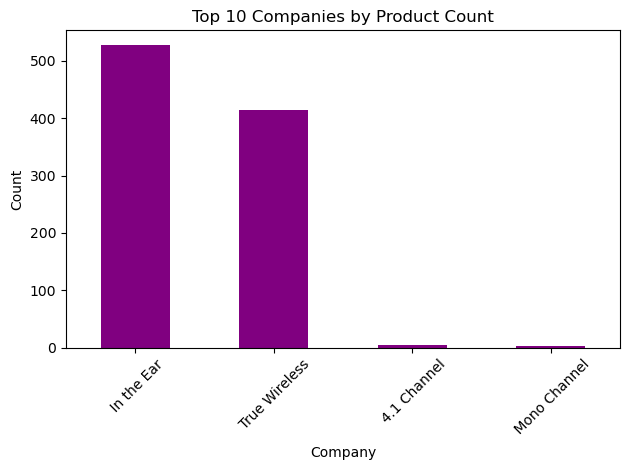

In [54]:

top_companies = df3['type'].value_counts()

plt.figure()
top_companies.plot(kind='bar', color='purple')

plt.xticks(rotation=45)
plt.title("Top 10 Companies by Product Count")
plt.xlabel("Company")
plt.ylabel("Count")
plt.tight_layout()
plt.show()

C:\ProgramData\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


<Axes: xlabel='type', ylabel='Count'>

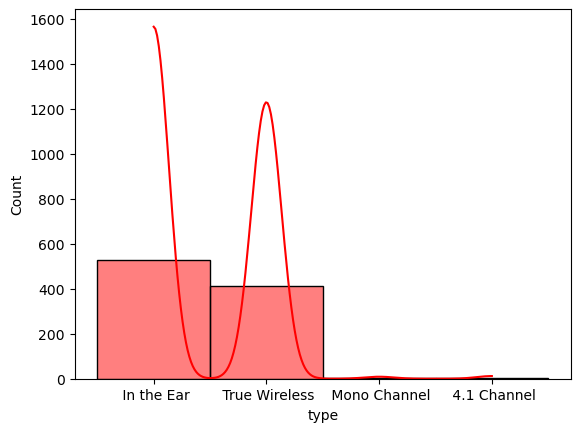

In [55]:
sns.histplot(df3['type'], kde=True , bins=50 , color='red')

In [56]:
df3['ratings'].value_counts()

ratings
4.0    189
3.7    125
3.8    123
3.9    122
4.1    107
4.2    102
3.6     65
3.5     28
4.3     20
3.4     16
3.3     11
4.5      8
3.2      7
4.4      6
5.0      5
4.7      5
3.1      3
4.6      2
2.7      1
4.8      1
2.0      1
2.2      1
Name: count, dtype: int64

C:\ProgramData\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


<Axes: xlabel='ratings', ylabel='Count'>

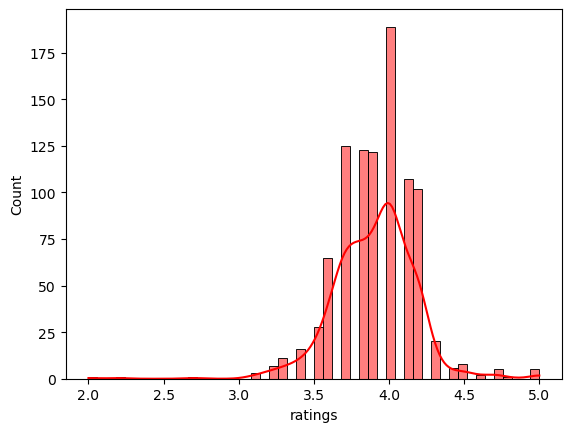

In [59]:
sns.histplot(df3['ratings'], kde=True , bins=50 , color='red')

In [60]:
df3['people_review'].value_counts()

people_review
14,276       31
8,896        29
47,151       24
1,88,519     23
6,182        21
20,048       20
1,11,172     20
3,27,645     17
308          14
49,704       13
6,379        11
4,05,147     10
3,128        10
6            10
1,24,994     10
1,47,072     10
13,45,614     9
3             9
4             9
2,992         8
72,798        8
1,09,649      7
2,40,115      7
13            7
22            6
20            5
21            5
66,986        5
30,198        5
81            5
50            5
1,94,790      5
2,86,234      4
26            4
81,506        4
58,311        4
19,628        4
7,225         4
3,975         4
39            4
5,06,991      4
1,801         4
10            4
2,551         4
9             4
43            4
1,62,560      4
20,871        4
28,901        4
65,327        4
10,964        3
131           3
1,367         3
10,586        3
2,144         3
324           3
389           3
4,882         3
52            3
19,277        3
9,849         3
7,076     

In [61]:
df3['people_review']

0       2,40,115
1       1,88,519
2       1,62,560
3         14,276
4         65,327
5       1,62,560
6       5,06,991
7         49,704
8       6,24,229
9            547
10           365
11      1,11,172
12     13,45,614
13      1,12,074
14      2,52,983
15        14,276
16         3,969
17        41,689
18        65,327
19        47,151
20        52,942
21           309
22        17,364
23        47,151
24      2,40,115
25      2,86,234
26      2,86,234
27         6,379
28        15,839
29      3,27,645
30        81,506
31         7,225
32           193
33         5,154
34           121
35        28,901
36      1,88,519
37      1,24,994
38            20
39         6,182
40         8,896
41      2,40,115
42      1,62,560
43      1,88,519
44        65,327
45      1,62,560
46        14,276
47      5,06,991
48      6,24,229
49           547
50      1,11,172
51           365
52     13,45,614
53      1,12,074
54        14,276
55      2,52,983
56         3,969
57        41,689
58        47,1

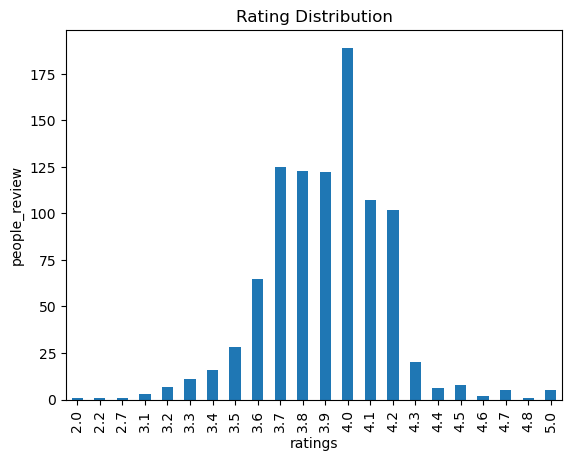

In [62]:
plt.figure()
df3['ratings'].value_counts().sort_index().plot(kind='bar')
plt.xlabel("ratings")
plt.ylabel("people_review")
plt.title("Rating Distribution")
plt.show()

In [63]:
# Group by product 
summary = df.groupby('product_name').agg(
    total_reviews=('reviews', 'count'),
    avg_rating=('ratings', 'mean')
).reset_index()

# Sort by total reviews (optional)
summary = summary.sort_values(by='total_reviews', ascending=False)

# Scatter Plot
plt.figure()
plt.scatter(summary['total_reviews'], summary['avg_rating'])

plt.xlabel("Number of Reviews")
plt.ylabel("Average Rating")
plt.title("Number of Reviews vs Average Rating")

plt.show()

NameError: name 'df' is not defined

In [64]:
print(df3[['ratings', 'people_review']].dtypes)

ratings          float64
people_review     object
dtype: object


In [65]:
df3['people_review'] = (
    df3['people_review']
    .astype(str)
    .str.replace(',', '')   # remove commas if like 1,234
    .astype(int)
)

df3['ratings'] = df3['ratings'].astype(float)

In [66]:
summary = df3.groupby('company').agg(
    total_reviews=('people_review', 'sum'),
    avg_rating=('ratings', 'mean')
).reset_index()

In [67]:
summary

,company,total_reviews,avg_rating
0,APPLE,34,3.300000
1,Alfanso,111280,3.766667
2,Aloof,211,3.600000
3,Aroma,5145897,3.861417
4,Auratic,188519,3.900000
5,Auxigen,17196,4.200000
6,BRICKFIRE,8448,4.100000
7,BULLSTORM,3251,3.850000
8,BeastBass,49704,4.000000
9,Beats,9,3.900000


The analysis of company reviews shows variation in both the number of reviews and average ratings among different companies. Aroma has the highest number of reviews (5,145,897) with a strong average rating of 3.86, indicating high popularity and consistent customer engagement. Alfanso and Auratic also have a large number of reviews with good ratings around 3.7–3.9, suggesting positive customer perception.

Some companies such as Auxigen, BRICKFIRE, and BeastBass have higher average ratings (4.0+), which indicates better customer satisfaction, although their total number of reviews is comparatively lower than companies like Aroma. APPLE has a moderate number of reviews but a relatively lower average rating (3.3), suggesting mixed customer feedback.

Overall, the dataset indicates that companies with extremely high review counts tend to maintain ratings around 3.7–3.9, while some smaller companies achieve higher ratings above 4.0 due to better customer satisfaction or niche markets.

In [68]:
df3['company']

0             Aroma
1          TECHFIRE
2             Aroma
3             Boult
4             Aroma
5             Aroma
6           OnePlus
7             Boult
8              boAt
9           MASOORI
10          Dozokil
11            Boult
12             boAt
13             boAt
14            Noise
15            Boult
16            Noise
17       Portronics
18            Aroma
19            Boult
20            Aroma
21           Lichen
22           ORAIMO
23            Boult
24            Aroma
25           realme
26           realme
27            PTron
28       Fire-Boltt
29             boAt
30             OPPO
31            Boult
32        Chitransh
33          Seashot
34       divinestar
35            Boult
36         TECHFIRE
37             boAt
38              U&i
39            Aroma
40            Aroma
41            Aroma
42            Aroma
43         TECHFIRE
44            Aroma
45            Aroma
46            Boult
47          OnePlus
48             boAt
49          MASOORI


In [69]:
summary = df3.groupby('company').agg(
    total_reviews=('people_review', 'sum'),
    avg_rating=('ratings', 'mean')
).reset_index()

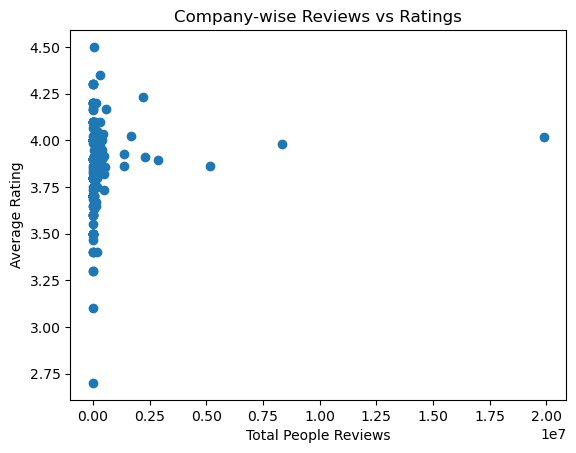

In [70]:
plt.figure()

plt.scatter(summary['total_reviews'], summary['avg_rating'])

plt.xlabel("Total People Reviews")
plt.ylabel("Average Rating")
plt.title("Company-wise Reviews vs Ratings")

plt.show()

In [71]:
df3['offer_price']

0        381
1        445
2        499
3       1299
4        395
5        499
6       1799
7        799
8       1199
9        499
10       488
11       999
12       899
13      1299
14      1299
15      1299
16      1499
17      1099
18       395
19      1099
20       431
21       299
22       499
23      1099
24       419
25      1299
26      1299
27       799
28       799
29      1099
30      1799
31      1299
32       439
33       639
34      1199
35       445
36       999
37       299
38       699
39       546
40       546
41       381
42       499
43       445
44       395
45       499
46      1299
47      1799
48      1199
49       499
50       999
51       488
52       899
53      1299
54      1299
55      1299
56      1499
57      1099
58      1099
59       395
60       431
61       299
62      1099
63       499
64       419
65      1299
66       449
67      1299
68       799
69      1799
70       799
71       439
72       639
73       546
74       445
75       999
76       299

In [72]:
df3['offer_price'].isnull().sum()

0

In [73]:
df3['real_price'].isnull().sum()

0

In [74]:
# Find invalid (NaN) values
invalid_real = df3[df3['real_price'].isna()]
invalid_offer = df3[df3['offer_price'].isna()]

print("Invalid real_price rows:")
print(invalid_real)

print("Invalid offer_price rows:")
print(invalid_offer)

# Find negative values
negative_real = df3[df3['real_price'] < 0]
negative_offer = df3[df3['offer_price'] < 0]

print("Negative real_price rows:")
print(negative_real)

print("Negative offer_price rows:")
print(negative_offer)

Invalid real_price rows:
Empty DataFrame
Columns: [Unnamed: 0, company, name, color, type, ratings, people_review, offer_price, real_price, offer, battery_hours, fast_charging, ENC, ANC, bluetooth_version, waterproof_rating]
Index: []
Invalid offer_price rows:
Empty DataFrame
Columns: [Unnamed: 0, company, name, color, type, ratings, people_review, offer_price, real_price, offer, battery_hours, fast_charging, ENC, ANC, bluetooth_version, waterproof_rating]
Index: []
Negative real_price rows:
Empty DataFrame
Columns: [Unnamed: 0, company, name, color, type, ratings, people_review, offer_price, real_price, offer, battery_hours, fast_charging, ENC, ANC, bluetooth_version, waterproof_rating]
Index: []
Negative offer_price rows:
Empty DataFrame
Columns: [Unnamed: 0, company, name, color, type, ratings, people_review, offer_price, real_price, offer, battery_hours, fast_charging, ENC, ANC, bluetooth_version, waterproof_rating]
Index: []


In [75]:
df3.head()

,Unnamed: 0,company,name,color,type,ratings,people_review,offer_price,real_price,offer,battery_hours,fast_charging,ENC,ANC,bluetooth_version,waterproof_rating
0,0,Aroma,NB119B Badshah - 40 Hours Playtime Bluetooth N...,Black,In the Ear,4.0,240115,381,1499,74% off,40,False,False,False,NaN,NaN
1,1,TECHFIRE,Fire 500v2 Neckband hi-bass Wireless Bluetooth...,Blue,In the Ear,3.9,188519,445,3850,88% off,NaN,False,False,False,...,NaN
2,2,Aroma,NB119 Titanium - 48 Hours Playtime Bluetooth N...,Blue,In the Ear,4.0,162560,499,2499,80% off,48,False,False,False,NaN,NaN
3,3,Boult,"Audio Z40 with Zen ENC Mic, 60H Battery Life, ...",White,In the Ear,4.2,14276,1299,4999,74% off,60,False,True,False,NaN,NaN
4,4,Aroma,NB119Pro Belief 48 Hours Playing Time Fast Cha...,Blue,In the Ear,4.0,65327,395,1999,80% off,48,True,False,False,NaN,NaN


In [76]:
df3['calculated_discount'] = (
    (df3['real_price'] - df3['offer_price']) / df3['real_price']
) * 100

# Round it
df3['calculated_discount'] = df3['calculated_discount'].round(2)

In [77]:
df3[['real_price', 'offer_price', 'offer', 'calculated_discount']].head()

,real_price,offer_price,offer,calculated_discount
0,1499,381,74% off,74.58
1,3850,445,88% off,88.44
2,2499,499,80% off,80.03
3,4999,1299,74% off,74.01
4,1999,395,80% off,80.24


In [78]:
# Actual Savings (Money Saved)
df3['amount_saved'] = df3['real_price'] - df3['offer_price']

In [79]:
df3.columns

Index(['Unnamed: 0', 'company', 'name', 'color', 'type', 'ratings',
       'people_review', 'offer_price', 'real_price', 'offer', 'battery_hours',
       'fast_charging', 'ENC', 'ANC', 'bluetooth_version', 'waterproof_rating',
       'calculated_discount', 'amount_saved'],
      dtype='object')

In [80]:
print(df3[['real_price', 'offer_price', 'calculated_discount']].corr())

                     real_price  offer_price  calculated_discount
real_price             1.000000     0.575724             0.243789
offer_price            0.575724     1.000000            -0.486693
calculated_discount    0.243789    -0.486693             1.000000


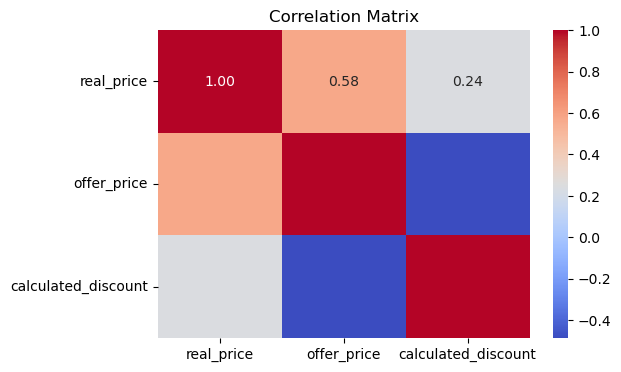

In [81]:
# Calculate correlation
corr = df3[['real_price', 'offer_price', 'calculated_discount']].corr()

# Plot heatmap
plt.figure(figsize=(6,4))
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt='.2f')

plt.title("Correlation Matrix")
plt.show()

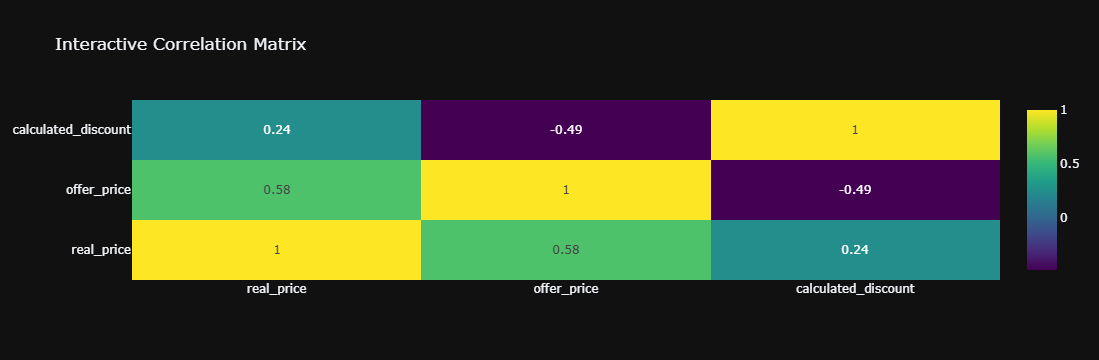

In [86]:
import plotly.graph_objects as go
import plotly.express as px
corr = df3[['real_price','offer_price','calculated_discount']].corr()

fig = go.Figure(data=go.Heatmap(
        z=corr.values,
        x=corr.columns,
        y=corr.columns,
        colorscale='Viridis',
        text=corr.round(2),
        texttemplate="%{text}",
        hoverongaps=False))

fig.update_layout(
    title="Interactive Correlation Matrix",
    template="plotly_dark"
)

fig.show()

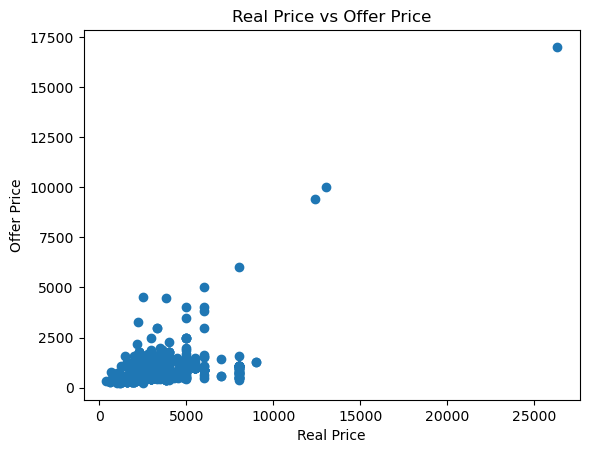

In [87]:
plt.figure()
plt.scatter(df3['real_price'], df3['offer_price'])
plt.xlabel("Real Price")
plt.ylabel("Offer Price")
plt.title("Real Price vs Offer Price")
plt.show()

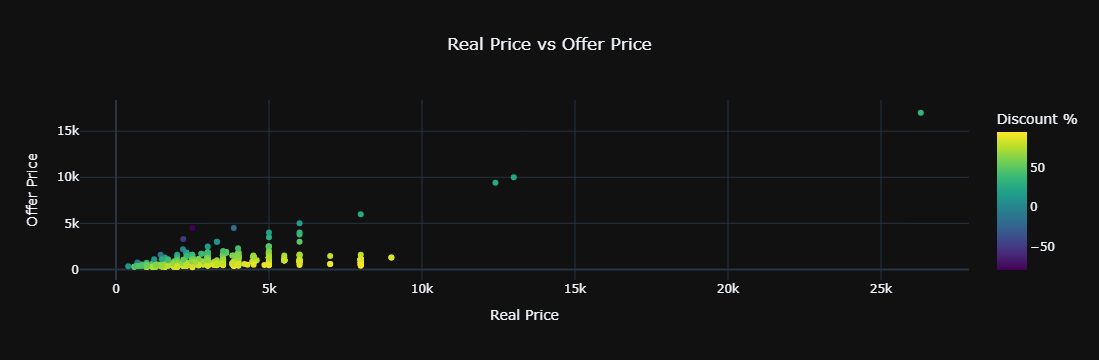

In [88]:
fig = px.scatter(
    df3,
    x='real_price',
    y='offer_price',
    color='calculated_discount',   # color based on discount
    color_continuous_scale='viridis',
    title='Real Price vs Offer Price',
    labels={
        'real_price': 'Real Price',
        'offer_price': 'Offer Price',
        'calculated_discount': 'Discount %'
    },
    hover_data=['real_price', 'offer_price', 'calculated_discount']
)

fig.update_layout(
    template='plotly_dark',
    title_x=0.5
)

fig.show()

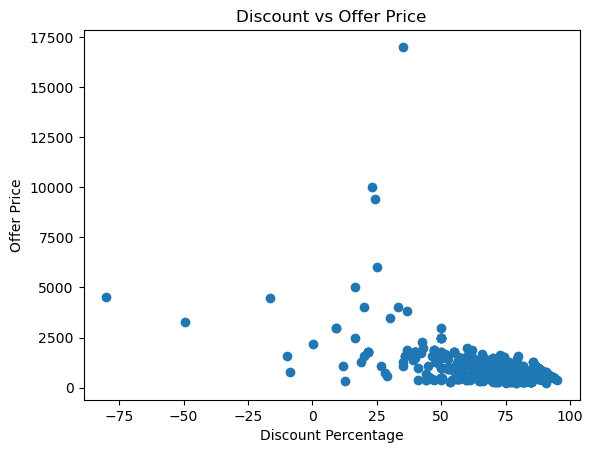

In [89]:
plt.figure()
plt.scatter(df3['calculated_discount'], df3['offer_price'])
plt.xlabel("Discount Percentage")
plt.ylabel("Offer Price")
plt.title("Discount vs Offer Price")
plt.show()

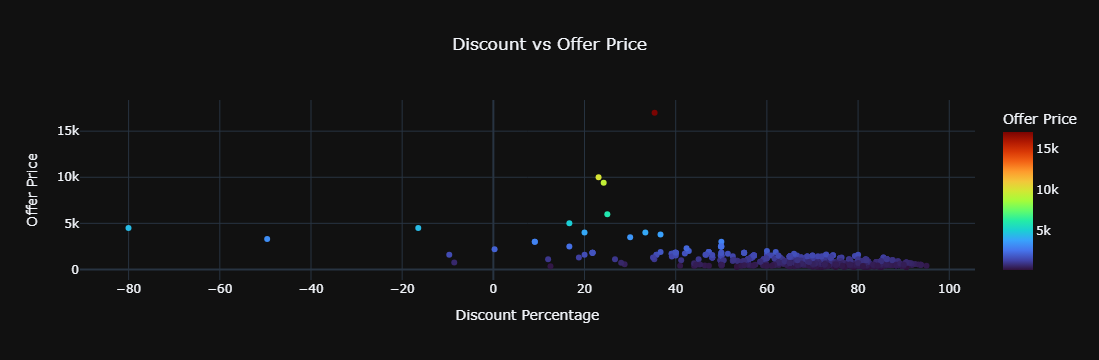

In [90]:
import plotly.express as px

fig = px.scatter(
    df3,
    x='calculated_discount',
    y='offer_price',
    color='offer_price',                 # color based on offer price
    color_continuous_scale='turbo',      # attractive color scale
    title='Discount vs Offer Price',
    labels={
        'calculated_discount': 'Discount Percentage',
        'offer_price': 'Offer Price'
    },
    hover_data=['calculated_discount', 'offer_price', 'real_price']
)

fig.update_layout(
    template='plotly_dark',
    title_x=0.5
)

fig.show()

In [91]:
df3[df3['calculated_discount'] < 0]

,Unnamed: 0,company,name,color,type,ratings,people_review,offer_price,real_price,offer,battery_hours,fast_charging,ENC,ANC,bluetooth_version,waterproof_rating,calculated_discount,amount_saved
687,687,SONY,WI-C310 Wireless In-Ear Headphones with Mic Bl...,Blue,In the Ear,3.8,50,3290,2199,67% off,NaN,False,False,False,NaN,NaN,-49.61,-1091
722,722,TECHFIRE,Fire-T10 -48 Hours Playing Time Fast Charging ...,OCEAN Blue,In the Ear,3.9,16582,759,699,66% off,48,True,False,False,NaN,NaN,-8.58,-60
814,814,realme,Buds Q2s with AI ENC & Fast Charging Bluetooth...,Paper White,True Wireless,3.5,22,1599,1458,65% off,NaN,True,True,False,NaN,NaN,-9.67,-141
823,823,Jabra,Talk 45 Bluetooth Headset,Silver,In the Ear,3.7,3072,4484,3850,88% off,NaN,False,False,False,NaN,NaN,-16.47,-634
868,868,Beats,"Flex - Apple W1 Headphone Chip, Class 1 Blueto...",Yuzu Yellow,In the Ear,3.9,9,4499,2499,56% off,1,False,False,False,...,NaN,-80.03,-2000


In [92]:
df3['calculated_discount'] = ((df3['real_price'] - df3['offer_price']) / df3['real_price']) * 100

In [93]:
df3['amount_saved'] = df3['real_price'] - df3['offer_price']

In [94]:
df3[df3['calculated_discount'] < 0]

,Unnamed: 0,company,name,color,type,ratings,people_review,offer_price,real_price,offer,battery_hours,fast_charging,ENC,ANC,bluetooth_version,waterproof_rating,calculated_discount,amount_saved
687,687,SONY,WI-C310 Wireless In-Ear Headphones with Mic Bl...,Blue,In the Ear,3.8,50,3290,2199,67% off,NaN,False,False,False,NaN,NaN,-49.613461,-1091
722,722,TECHFIRE,Fire-T10 -48 Hours Playing Time Fast Charging ...,OCEAN Blue,In the Ear,3.9,16582,759,699,66% off,48,True,False,False,NaN,NaN,-8.583691,-60
814,814,realme,Buds Q2s with AI ENC & Fast Charging Bluetooth...,Paper White,True Wireless,3.5,22,1599,1458,65% off,NaN,True,True,False,NaN,NaN,-9.670782,-141
823,823,Jabra,Talk 45 Bluetooth Headset,Silver,In the Ear,3.7,3072,4484,3850,88% off,NaN,False,False,False,NaN,NaN,-16.467532,-634
868,868,Beats,"Flex - Apple W1 Headphone Chip, Class 1 Blueto...",Yuzu Yellow,In the Ear,3.9,9,4499,2499,56% off,1,False,False,False,...,NaN,-80.032013,-2000


In [95]:
df3 = df3[df3['calculated_discount'] >= 0]

In [96]:
print("Rows removed:", len(df3[df3['calculated_discount'] < 0]))

Rows removed: 0


In [97]:
df3[df3['calculated_discount'] < 0]

,Unnamed: 0,company,name,color,type,ratings,people_review,offer_price,real_price,offer,battery_hours,fast_charging,ENC,ANC,bluetooth_version,waterproof_rating,calculated_discount,amount_saved


In [98]:
df3.shape

(943, 18)

In [99]:
df3.columns

Index(['Unnamed: 0', 'company', 'name', 'color', 'type', 'ratings',
       'people_review', 'offer_price', 'real_price', 'offer', 'battery_hours',
       'fast_charging', 'ENC', 'ANC', 'bluetooth_version', 'waterproof_rating',
       'calculated_discount', 'amount_saved'],
      dtype='object')

Correlation Analysis Explanation (Business Perspective)

This correlation matrix shows the relationship between Real Price, Offer Price, and Calculated Discount.

Real Price vs Offer Price (0.58 – Moderate Positive Correlation)
This means that when the real price of a product increases, the offer price also tends to increase. Higher priced products usually still remain expensive even after discounts.

Real Price vs Discount (0.24 – Weak Positive Correlation)
This indicates that more expensive products sometimes get slightly higher discounts, but the relationship is weak. Pricing strategies are not strongly dependent on the product’s original price.

Offer Price vs Discount (-0.49 – Moderate Negative Correlation)
This shows that as discount percentage increases, the offer price decreases. This is expected behavior because larger discounts reduce the final selling price.

Business Insights

From this analysis, businesses can understand that:

Discount strategies directly affect the final selling price of products.

Products with higher real prices still maintain relatively higher offer prices, even after discounts.

Increasing discount percentages can significantly lower the offer price, which may attract more customers.

Recommendation for Business

Based on this data:

Businesses can use higher discounts strategically on high-priced products to increase sales.

Moderate discounts can be used to maintain profitability while keeping prices competitive.

Understanding this relationship helps companies optimize pricing strategies to balance revenue and customer attraction.

# Do higher discounts mean higher ratings?

In [100]:
df3[['ratings', 'calculated_discount']].corr()

,ratings,calculated_discount
ratings,1.00000,-0.08052
calculated_discount,-0.08052,1.00000


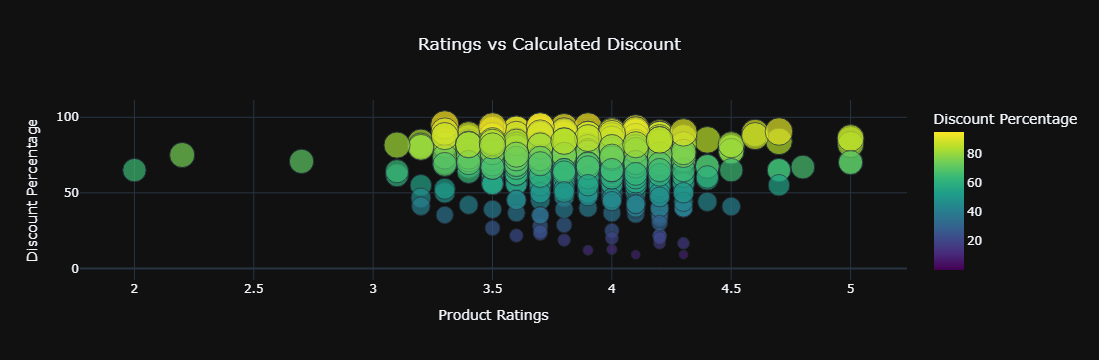

In [101]:
fig = px.scatter(
    df3,
    x='ratings',
    y='calculated_discount',
    color='calculated_discount',
    size='calculated_discount',
    color_continuous_scale='viridis',
    title='Ratings vs Calculated Discount',
    labels={
        'ratings': 'Product Ratings',
        'calculated_discount': 'Discount Percentage'
    },
    hover_data=['ratings', 'calculated_discount']
)

fig.update_layout(
    template='plotly_dark',
    title_x=0.5
)

fig.show()

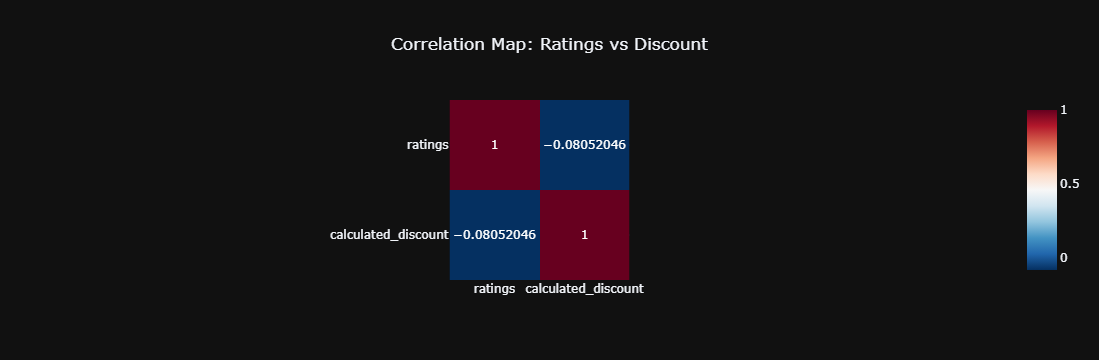

In [102]:
# Calculate correlation
corr = df3[['ratings', 'calculated_discount']].corr()

# Plot heatmap
fig = px.imshow(
    corr,
    text_auto=True,
    color_continuous_scale='RdBu_r',
    title='Correlation Map: Ratings vs Discount'
)

fig.update_layout(
    template='plotly_dark',
    title_x=0.5
)

fig.show()

From the correlation heatmap, the correlation value between ratings and calculated_discount is approximately -0.08.

Interpretation

The correlation value -0.08 is very close to 0, which means there is almost no relationship between product ratings and the discount offered.

The slightly negative value indicates a very weak negative relationship, meaning that products with higher ratings may sometimes receive slightly lower discounts, but the effect is extremely small and practically negligible.

Key Insight (Important Observation)

Interestingly, from a theoretical business perspective, one might expect a stronger relationship between ratings and discounts. For example:

Products with lower ratings might be given higher discounts to increase sales.

Products with higher ratings might receive lower discounts because they already perform well in the market.

However, the analysis shows that ratings and discounts are largely independent of each other in this dataset.

Business Conclusion

This suggests that businesses may not be using product ratings as a primary factor when deciding discount strategies. Instead, discounts might be determined by other factors such as:

Inventory clearance

Seasonal promotions

Competitive pricing

Marketing campaigns

Product category or brand strategy

Final Conclusion

## Create Value For Money Score

In [103]:
df3['value_score'] = df3['ratings'] * df3['calculated_discount']

C:\Users\DEEL\AppData\Local\Temp\ipykernel_10672\2098875458.py:1: SettingWithCopyWarning:


A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy



In [104]:
df3.sort_values(by='value_score', ascending=False).head()

,Unnamed: 0,company,name,color,type,ratings,people_review,offer_price,real_price,offer,battery_hours,fast_charging,ENC,ANC,bluetooth_version,waterproof_rating,calculated_discount,amount_saved,value_score
415,415,Boult,"Audio Truebuds with 30H Battery, IPX7 Waterpro...",Red,True Wireless,5.0,3,1099,7999,86% off,30,False,False,False,NaN,IPX7,86.260783,6900,431.303913
723,723,Digiwins,BTH F9 Pro Earbuds Upto 300Hrs Playtime With 2...,Black,True Wireless,4.7,81,235,2499,78% off,300,False,False,False,NaN,NaN,90.596238,2264,425.802321
274,274,Digiwins,B235 Neckband With ASAP Fast Charging Stereo S...,Black,In the Ear,5.0,14,449,2999,85% off,NaN,True,False,False,NaN,NaN,85.028343,2550,425.141714
147,147,TECHFIRE,Fire-T10 -48 Hours Playing Time Fast Charging ...,OCEAN Blue,In the Ear,4.6,9,399,3850,89% off,48,True,False,False,NaN,NaN,89.636364,3451,412.327273
325,325,Lichen,B11 Neckband Bluetooth Headset Earphone Sports...,Blue,In the Ear,5.0,4,288,1599,81% off,NaN,False,False,False,NaN,NaN,81.988743,1311,409.943715


In [105]:
df3['value_score'].value_counts()

value_score
310.862172    19
268.939470    15
335.515548    11
260.130065    11
261.670835    11
280.093364    10
327.790974    10
328.961992     8
344.516883     7
256.252405     7
283.476738     7
303.460692     6
320.128051     6
273.068267     6
229.040161     6
306.768923     6
201.680672     5
266.088696     5
290.745373     5
305.282641     5
320.091455     5
320.960480     5
344.922078     5
232.410804     5
319.263853     4
357.178589     4
314.552425     4
221.709007     4
279.732441     4
302.401201     4
340.618182     4
296.059212     4
172.057352     4
284.507668     4
231.057764     4
246.831221     4
331.274467     4
353.669209     3
357.059510     3
240.620310     3
371.018182     3
273.091030     3
360.120040     3
327.731092     3
256.160000     3
286.933490     3
278.759587     3
312.062412     3
91.344063      3
220.565217     3
234.352672     3
315.098366     3
253.502335     3
332.933173     3
304.060812     2
310.262172     2
305.735000     2
316.772257     2
18

## Categorize Products

In [106]:
df3['discount_category'] = pd.cut(
    df3['calculated_discount'],
    bins=[0, 20, 40, 60, 100],
    labels=['Low', 'Medium', 'High', 'Very High']
)

C:\Users\DEEL\AppData\Local\Temp\ipykernel_10672\404325897.py:1: SettingWithCopyWarning:


A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy



In [107]:
df3.groupby('discount_category')['ratings'].mean()

C:\Users\DEEL\AppData\Local\Temp\ipykernel_10672\704511237.py:1: FutureWarning:

The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.



discount_category
Low          4.100000
Medium       3.907692
High         3.951825
Very High    3.894301
Name: ratings, dtype: float64

C:\Users\DEEL\AppData\Local\Temp\ipykernel_10672\1748360782.py:1: FutureWarning:

The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.



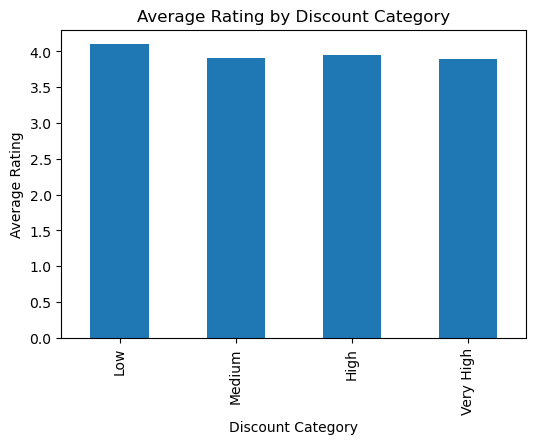

In [108]:
avg_rating = df3.groupby('discount_category')['ratings'].mean()

plt.figure(figsize=(6,4))
avg_rating.plot(kind='bar')

plt.xlabel("Discount Category")
plt.ylabel("Average Rating")
plt.title("Average Rating by Discount Category")

plt.show()

C:\Users\DEEL\AppData\Local\Temp\ipykernel_10672\3965505432.py:1: FutureWarning:

The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.



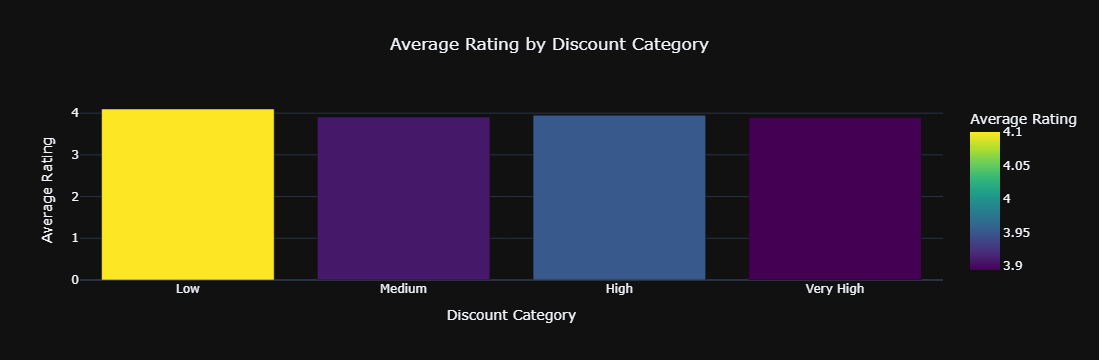

In [109]:
avg_rating = df3.groupby('discount_category')['ratings'].mean().reset_index()

fig = px.bar(
    avg_rating,
    x='discount_category',
    y='ratings',
    color='ratings',
    title='Average Rating by Discount Category',
    labels={
        'discount_category': 'Discount Category',
        'ratings': 'Average Rating'
    },
    color_continuous_scale='viridis'
)

fig.update_layout(
    template='plotly_dark',
    title_x=0.5
)

fig.show()

In [110]:
df3.columns

Index(['Unnamed: 0', 'company', 'name', 'color', 'type', 'ratings',
       'people_review', 'offer_price', 'real_price', 'offer', 'battery_hours',
       'fast_charging', 'ENC', 'ANC', 'bluetooth_version', 'waterproof_rating',
       'calculated_discount', 'amount_saved', 'value_score',
       'discount_category'],
      dtype='object')

In [111]:
df3['battery_hours'].value_counts().isnull().sum()

0

In [112]:
df3['fast_charging'].value_counts()

fast_charging
False    829
True     114
Name: count, dtype: int64

In [113]:
df3['fast_charging'].value_counts().isnull().sum()

0

In [114]:
df3['fast_charging']

0      False
1      False
2      False
3      False
4       True
5      False
6       True
7      False
8      False
9      False
10     False
11      True
12     False
13     False
14     False
15     False
16     False
17     False
18      True
19     False
20      True
21     False
22     False
23     False
24      True
25      True
26      True
27     False
28     False
29     False
30     False
31     False
32     False
33     False
34     False
35     False
36     False
37     False
38     False
39     False
40     False
41     False
42     False
43     False
44      True
45     False
46     False
47      True
48     False
49     False
50      True
51     False
52     False
53     False
54     False
55     False
56     False
57     False
58     False
59      True
60      True
61     False
62     False
63     False
64      True
65      True
66     False
67      True
68     False
69     False
70     False
71     False
72     False
73     False
74     False
75     False
76     False

In [115]:
df3['ENC'].value_counts()

ENC
False    802
True     141
Name: count, dtype: int64

In [116]:
df3['ANC'].value_counts()

ANC
False    919
True      24
Name: count, dtype: int64

In [117]:
df3['ENC'].isnull().sum()

0

In [118]:
df3['bluetooth_version'].value_counts()

bluetooth_version
...    19
5.0    14
5.1     6
5.2     3
5.3     2
Name: count, dtype: int64

In [119]:
df3['bluetooth_version'].isnull().sum()

899

In [120]:
df3['bluetooth_version'].isnull().mean() * 100

95.3340402969247

In [121]:
df3.drop(columns=['bluetooth_version'], inplace=True)

C:\Users\DEEL\AppData\Local\Temp\ipykernel_10672\1886065702.py:1: SettingWithCopyWarning:


A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy



In [122]:
df3['waterproof_rating'].isnull().sum()

916

In [123]:
df3['waterproof_rating'].value_counts()

waterproof_rating
IPX7    22
IPX5     3
IPX4     2
Name: count, dtype: int64

In [124]:
df3['waterproof_rating'].isnull().mean() * 100

97.13679745493107

In [125]:
df3.drop(columns=['waterproof_rating'], inplace=True)

C:\Users\DEEL\AppData\Local\Temp\ipykernel_10672\1115653658.py:1: SettingWithCopyWarning:


A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy



## The columns bluetooth_version and waterproof_rating contained extremely high missing values (95% and 97% respectively). Due to the sparsity of the data and the inability to derive reliable insights, these columns were removed during the data cleaning stage.

🔋 battery_hours

How many hours the earphones work on one full charge.
Higher = better convenience.

⚡ fast_charging

Does it support quick charge? (Yes/No)
Example: 10 min charge → 2 hours playtime.

🔇 ENC (Environmental Noise Cancellation)

ENC reduces background noise during calls.
Good for:

Office calls

Outdoor calls

Traffic environment

It improves microphone clarity, not music.

🎵 ANC (Active Noise Cancellation)

ANC reduces outside noise while listening to music.

Example:

Airplane noise

Traffic noise

Crowd noise

Very premium feature.

📶 bluetooth_version

Example: 4.2, 5.0, 5.1, 5.2

Higher version =

Better connection

Lower latency

Better battery efficiency

💧 waterproof_rating

Like:

IPX4

IPX5

IPX7

Higher number = more water resistant.

Example:

IPX4 → sweat resistant

IPX7 → water immersion resistant

In [126]:
df3.head()

,Unnamed: 0,company,name,color,type,ratings,people_review,offer_price,real_price,offer,battery_hours,fast_charging,ENC,ANC,calculated_discount,amount_saved,value_score,discount_category
0,0,Aroma,NB119B Badshah - 40 Hours Playtime Bluetooth N...,Black,In the Ear,4.0,240115,381,1499,74% off,40,False,False,False,74.583055,1118,298.332221,Very High
1,1,TECHFIRE,Fire 500v2 Neckband hi-bass Wireless Bluetooth...,Blue,In the Ear,3.9,188519,445,3850,88% off,NaN,False,False,False,88.441558,3405,344.922078,Very High
2,2,Aroma,NB119 Titanium - 48 Hours Playtime Bluetooth N...,Blue,In the Ear,4.0,162560,499,2499,80% off,48,False,False,False,80.032013,2000,320.128051,Very High
3,3,Boult,"Audio Z40 with Zen ENC Mic, 60H Battery Life, ...",White,In the Ear,4.2,14276,1299,4999,74% off,60,False,True,False,74.014803,3700,310.862172,Very High
4,4,Aroma,NB119Pro Belief 48 Hours Playing Time Fast Cha...,Blue,In the Ear,4.0,65327,395,1999,80% off,48,True,False,False,80.240120,1604,320.960480,Very High


In [127]:
df3.groupby('ANC')['ratings'].mean()
df3.groupby('ENC')['ratings'].mean()
df3.groupby('fast_charging')['ratings'].mean()

fast_charging
False    3.896261
True     3.966667
Name: ratings, dtype: float64

In [128]:
df3[['battery_hours', 'ratings']].corr()

,battery_hours,ratings
battery_hours,1.00000,-0.04863
ratings,-0.04863,1.00000


In [129]:
df3.groupby('fast_charging')['ratings'].mean()

fast_charging
False    3.896261
True     3.966667
Name: ratings, dtype: float64

In [130]:
df3.groupby('ENC')['ratings'].mean()

ENC
False    3.888155
True     3.999291
Name: ratings, dtype: float64

In [131]:
df3.groupby('ANC')['ratings'].mean()

ANC
False    3.903591
True     3.950000
Name: ratings, dtype: float64

In [132]:
df3['feature__score'] = (
    df3['ANC'].map({'True':1,'False':0}) +
    df3['ENC'].map({'True':1,'False':0})
)

C:\Users\DEEL\AppData\Local\Temp\ipykernel_10672\2089859909.py:1: SettingWithCopyWarning:


A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy



In [133]:
df3['feature__score']

0     NaN
1     NaN
2     NaN
3     NaN
4     NaN
5     NaN
6     NaN
7     NaN
8     NaN
9     NaN
10    NaN
11    NaN
12    NaN
13    NaN
14    NaN
15    NaN
16    NaN
17    NaN
18    NaN
19    NaN
20    NaN
21    NaN
22    NaN
23    NaN
24    NaN
25    NaN
26    NaN
27    NaN
28    NaN
29    NaN
30    NaN
31    NaN
32    NaN
33    NaN
34    NaN
35    NaN
36    NaN
37    NaN
38    NaN
39    NaN
40    NaN
41    NaN
42    NaN
43    NaN
44    NaN
45    NaN
46    NaN
47    NaN
48    NaN
49    NaN
50    NaN
51    NaN
52    NaN
53    NaN
54    NaN
55    NaN
56    NaN
57    NaN
58    NaN
59    NaN
60    NaN
61    NaN
62    NaN
63    NaN
64    NaN
65    NaN
66    NaN
67    NaN
68    NaN
69    NaN
70    NaN
71    NaN
72    NaN
73    NaN
74    NaN
75    NaN
76    NaN
77    NaN
78    NaN
79    NaN
80    NaN
81    NaN
82    NaN
83    NaN
84    NaN
85    NaN
86    NaN
87    NaN
88    NaN
89    NaN
90    NaN
91    NaN
92    NaN
93    NaN
94    NaN
95    NaN
96    NaN
97    NaN
98    NaN
99    NaN


In [134]:
df3['ANC']

0      False
1      False
2      False
3      False
4      False
5      False
6      False
7      False
8      False
9      False
10     False
11     False
12     False
13     False
14     False
15     False
16     False
17     False
18     False
19     False
20     False
21     False
22     False
23     False
24     False
25     False
26     False
27     False
28     False
29     False
30     False
31     False
32     False
33     False
34      True
35     False
36     False
37     False
38     False
39     False
40     False
41     False
42     False
43     False
44     False
45     False
46     False
47     False
48     False
49     False
50     False
51     False
52     False
53     False
54     False
55     False
56     False
57     False
58     False
59     False
60     False
61     False
62     False
63     False
64     False
65     False
66     False
67     False
68     False
69     False
70     False
71     False
72     False
73      True
74     False
75     False
76     False

In [135]:
df3.columns

Index(['Unnamed: 0', 'company', 'name', 'color', 'type', 'ratings',
       'people_review', 'offer_price', 'real_price', 'offer', 'battery_hours',
       'fast_charging', 'ENC', 'ANC', 'calculated_discount', 'amount_saved',
       'value_score', 'discount_category', 'feature__score'],
      dtype='object')

In [136]:
df3.drop(columns=['feature_score','feature__score'], inplace=True)

KeyError: "['feature_score'] not found in axis"

In [ ]:
df3[['battery_hours','ratings']].corr()

In [ ]:
df3.drop(columns=['feature_count'], inplace=True)

In [ ]:
df3['feature_count'].isnull().sum()

In [ ]:
df3['fast_charging'].isnull().sum()

In [ ]:
df3['fast_charging']

In [ ]:
df3['feature_count'] = (
    df3['ANC'].map({True:1, False:0}) +
    df3['ENC'].map({True:1, False:0}) +
    df3['fast_charging'].map({True:1, False:0})
)

In [ ]:
df3['feature_count']

In [ ]:
df3.groupby('feature_count')['ratings'].mean()

In [ ]:
feature_rating = df3.groupby('feature_count')['ratings'].mean().reset_index()

fig = px.bar(
    feature_rating,
    x='feature_count',
    y='ratings',
    color='ratings',
    title='Average Ratings by Feature Count',
    labels={
        'feature_count': 'Number of Features',
        'ratings': 'Average Rating'
    },
    color_continuous_scale='viridis'
)

fig.update_layout(
    template='plotly_dark',
    title_x=0.5
)

fig.show()

### Business Conclusion

Products with more premium features (ANC, ENC, Fast Charging) tend to receive slightly higher customer ratings. The average rating increases as the number of features increases, suggesting that additional features improve the overall user experience and perceived product quality.

Business Insight

This indicates that customers value functional features, and including more useful features can positively influence product satisfaction and reviews.

Recommendation

Companies should focus on adding practical features such as ANC, ENC, and fast charging, as these features may improve customer perception and increase product ratings.

In [137]:
df3[['calculated_discount','feature_count','ratings']].corr()

KeyError: "['feature_count'] not in index"

### Business Conclusion

The correlation results show that discounts have almost no relationship with product features or customer ratings. However, there is a small positive relationship between feature count and ratings, meaning products with more features tend to receive slightly better ratings.

Business Insight

This suggests that customer satisfaction is more influenced by product features than by discounts. Discounts alone may not significantly improve ratings or product perception.

Recommendation

Instead of relying heavily on discount strategies, businesses should focus on product innovation and feature improvements to increase customer satisfaction and long-term brand value.

In [138]:
corr = df3[['calculated_discount','feature_count','ratings']].corr()

fig = px.imshow(
    corr,
    text_auto=True,
    color_continuous_scale='RdBu_r',
    title='Correlation Map: Discount, Features, and Ratings'
)

fig.update_layout(
    template='plotly_dark',
    title_x=0.5
)

fig.show()

KeyError: "['feature_count'] not in index"

In [139]:
df3.columns

Index(['Unnamed: 0', 'company', 'name', 'color', 'type', 'ratings',
       'people_review', 'offer_price', 'real_price', 'offer', 'battery_hours',
       'fast_charging', 'ENC', 'ANC', 'calculated_discount', 'amount_saved',
       'value_score', 'discount_category', 'feature__score'],
      dtype='object')

In [140]:
df3[['real_price','offer_price','ratings']].describe()

,real_price,offer_price,ratings
count,943.000000,943.000000,943.000000
mean,3237.664899,871.489926,3.904772
std,1856.789999,839.125670,0.275597
min,399.000000,235.000000,2.000000
25%,1999.000000,499.000000,3.700000
50%,2990.000000,699.000000,3.900000
75%,3994.500000,1099.000000,4.100000
max,26300.000000,16999.000000,5.000000


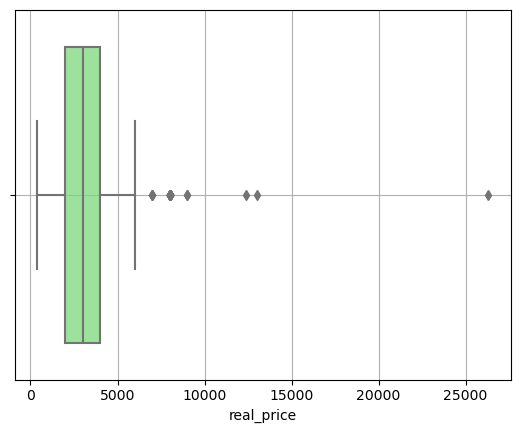

In [141]:
sns.boxplot(x=df3['real_price'],color='lightgreen')
plt.grid()

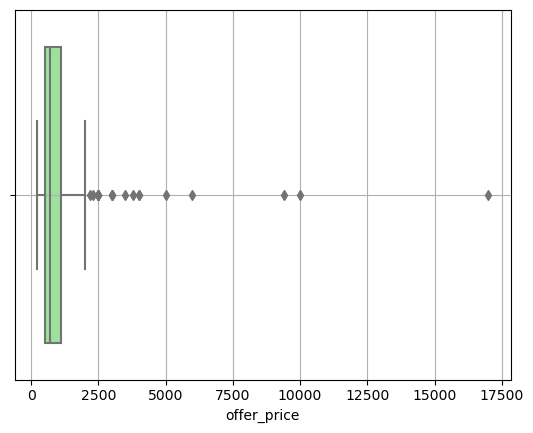

In [142]:
sns.boxplot(x=df3['offer_price'],color='lightgreen')
plt.grid()

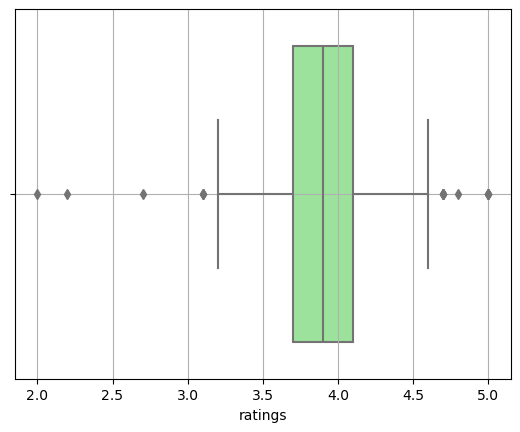

In [143]:
sns.boxplot(x=df3['ratings'],color='lightgreen')
plt.grid()

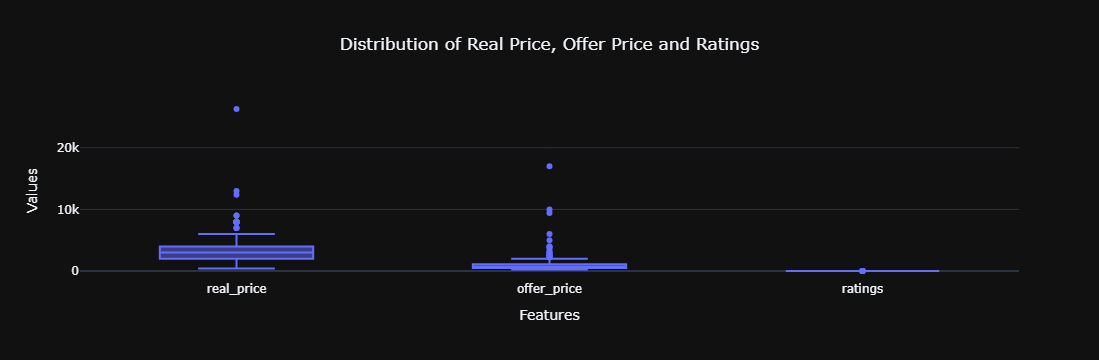

In [144]:
fig = px.box(
    df3[['real_price','offer_price','ratings']],
    title='Distribution of Real Price, Offer Price and Ratings'
)

fig.update_layout(
    template='plotly_dark',
    title_x=0.5,
    xaxis_title="Features",
    yaxis_title="Values"
)

fig.show()

C:\ProgramData\anaconda3\Lib\site-packages\seaborn\matrix.py:260: FutureWarning:

Format strings passed to MaskedConstant are ignored, but in future may error or produce different behavior



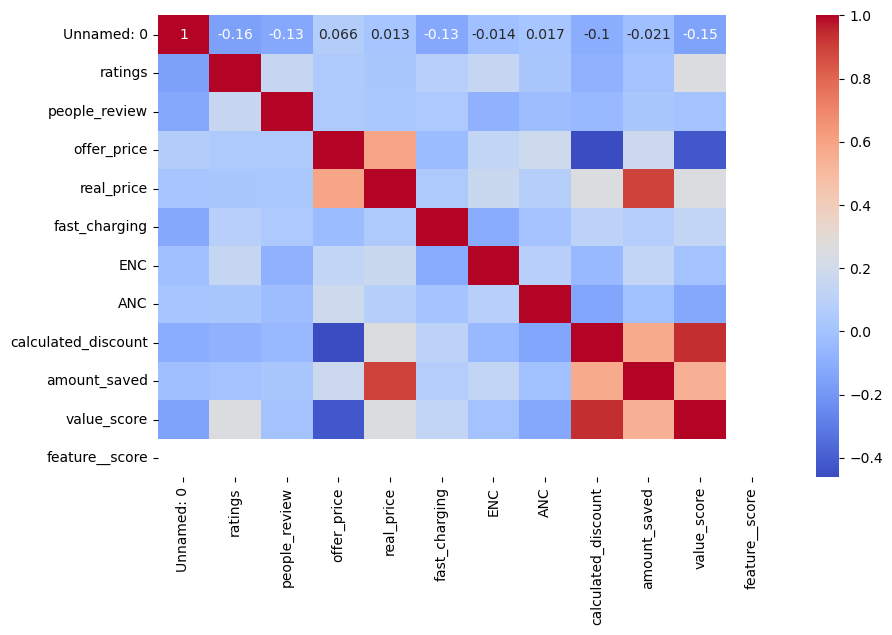

In [145]:
plt.figure(figsize=(10,6))
sns.heatmap(df3.corr(numeric_only=True), annot=True, cmap='coolwarm')
plt.show()

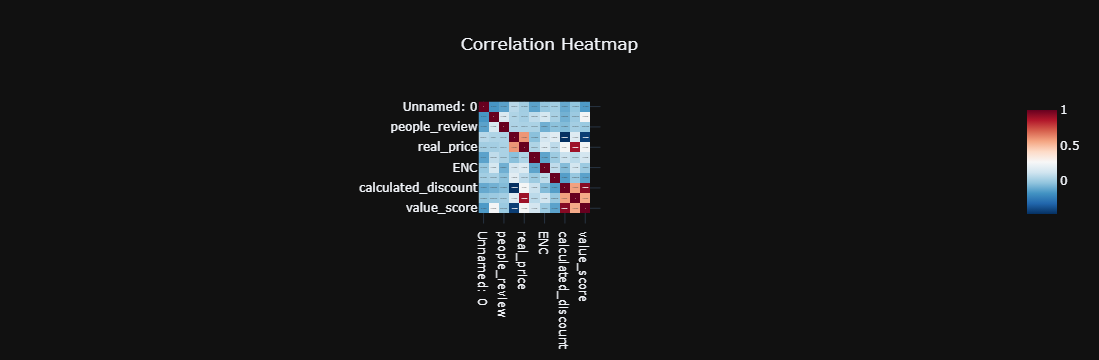

In [146]:
# Calculate correlation
corr = df3.corr(numeric_only=True)

# Interactive heatmap
fig = px.imshow(
    corr,
    text_auto=True,
    color_continuous_scale='RdBu_r',
    title="Correlation Heatmap"
)

fig.update_layout(
    template='plotly_dark',
    title_x=0.5
)

fig.show()

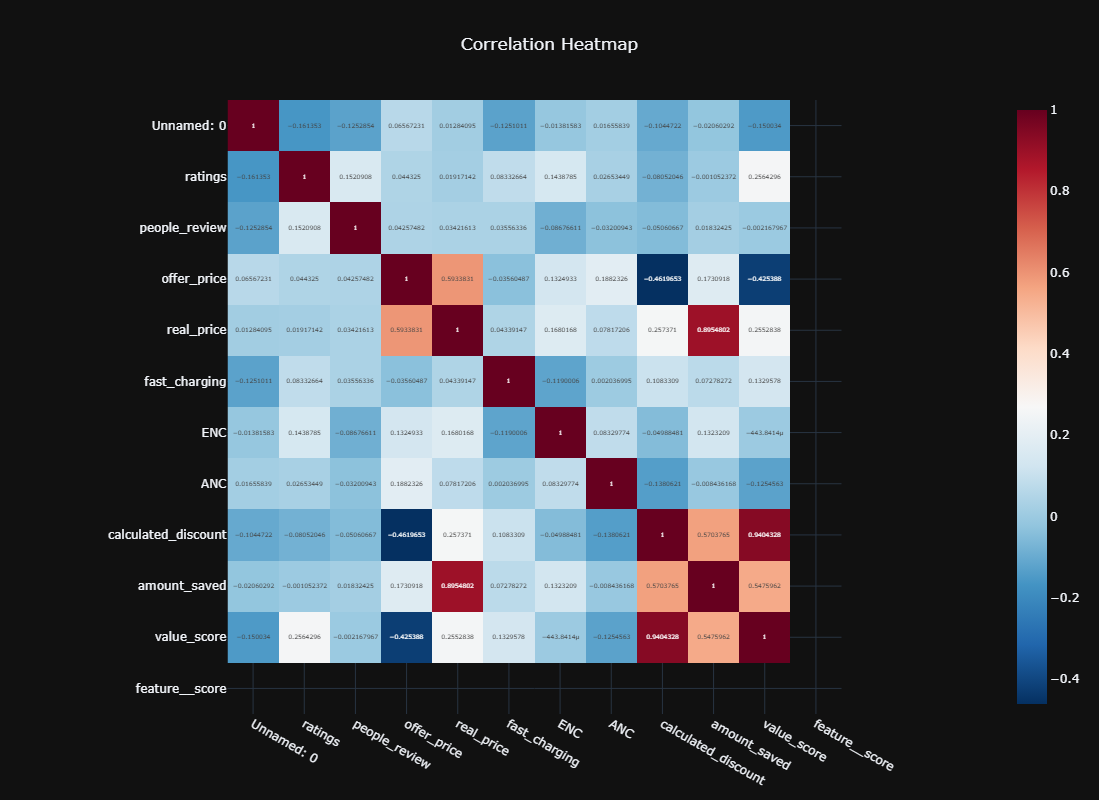

In [147]:
import plotly.express as px

# Calculate correlation
corr = df3.corr(numeric_only=True)

fig = px.imshow(
    corr,
    text_auto=True,
    color_continuous_scale='RdBu_r',
    title="Correlation Heatmap"
)

fig.update_layout(
    template='plotly_dark',
    title_x=0.5,
    width=1000,      # increase width
    height=800       # increase height
)

fig.show()

# MODEL 1: Rating Prediction Model

In [222]:
# 1️⃣ Define Target and Features
X = df3.drop(columns=['ratings', 'name', 'Unnamed: 0'])
y = df3['ratings']

# Automatically detect column types
numeric_features = X.select_dtypes(include=['int64', 'float64']).columns
categorical_features = X.select_dtypes(include=['object', 'category']).columns
# 2️⃣ Preprocessing Pipelines
numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore'))
])

preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, numeric_features),
        ('cat', categorical_transformer, categorical_features)
    ]
)

# ------------------------------------------------
# 3️⃣ Full Pipeline
# ------------------------------------------------

model_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('model', RandomForestRegressor(
        n_estimators=200,
        random_state=42
    ))
])

# ------------------------------------------------
# 4️⃣ Train-Test Split
# ------------------------------------------------

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

# ------------------------------------------------
# 5️⃣ Train
# ------------------------------------------------

model_pipeline.fit(X_train, y_train)

# ------------------------------------------------
# 6️⃣ Evaluate
# ------------------------------------------------

y_pred = model_pipeline.predict(X_test)

print("R2 Score:", r2_score(y_test, y_pred))
print("MAE:", mean_absolute_error(y_test, y_pred))

R2 Score: 0.7948871367145813
MAE: 0.06648148148148106


In [224]:
from sklearn.model_selection import cross_val_score

cv_scores = cross_val_score(
    model_pipeline,
    X,
    y,
    cv=5,
    scoring='r2'
)

print("Cross Validation R2 Scores:", cv_scores)
print("Average CV R2:", cv_scores.mean())

Cross Validation R2 Scores: [0.90855335 0.86248419 0.88601671 0.82434547 0.45656337]
Average CV R2: 0.7875926181731898


In [225]:
model = model_pipeline.named_steps['model']
feature_names = model_pipeline.named_steps['preprocessor'].get_feature_names_out()

importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': model.feature_importances_
}).sort_values(by='Importance', ascending=False)

print(importance_df.head(10))

                      Feature  Importance
4            num__value_score    0.418292
2    num__calculated_discount    0.275203
0            num__offer_price    0.069203
3           num__amount_saved    0.042245
114        cat__company_SYARA    0.027356
191    cat__color_Cobalt Blue    0.019467
1             num__real_price    0.014745
217    cat__color_Lunar White    0.004473
83          cat__company_Mivi    0.004267
75        cat__company_MEDIAL    0.004215


In [226]:
import pandas as pd
import numpy as np

from sklearn.model_selection import cross_val_score
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer

from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.linear_model import LinearRegression

# Optional (if installed)
try:
    from xgboost import XGBRegressor
    xgb_available = True
except:
    xgb_available = False

# ------------------------------------------------
# 1️⃣ Prepare Data
# ------------------------------------------------

X = df3.drop(columns=['ratings', 'name', 'Unnamed: 0'])
y = df3['ratings']

numeric_features = X.select_dtypes(include=['int64', 'float64']).columns
categorical_features = X.select_dtypes(include=['object', 'category']).columns

# ------------------------------------------------
# 2️⃣ Preprocessing
# ------------------------------------------------

numeric_transformer = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

categorical_transformer = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore'))
])

preprocessor = ColumnTransformer([
    ('num', numeric_transformer, numeric_features),
    ('cat', categorical_transformer, categorical_features)
])

# ------------------------------------------------
# 3️⃣ Define Models
# ------------------------------------------------

models = {
    "RandomForest": RandomForestRegressor(n_estimators=200, random_state=42),
    "GradientBoosting": GradientBoostingRegressor(random_state=42),
    "LinearRegression": LinearRegression()
}

if xgb_available:
    models["XGBoost"] = XGBRegressor(
        n_estimators=200,
        random_state=42,
        verbosity=0
    )

# ------------------------------------------------
# 4️⃣ Train + Evaluate All Models
# ------------------------------------------------

results = []
trained_models = {}

for name, model in models.items():

    pipeline = Pipeline([
        ('preprocessor', preprocessor),
        ('model', model)
    ])

    cv_scores = cross_val_score(
        pipeline,
        X,
        y,
        cv=5,
        scoring='r2'
    )

    results.append({
        "Model": name,
        "Mean_R2": cv_scores.mean(),
        "Std_R2": cv_scores.std()
    })

    trained_models[name] = pipeline

# ------------------------------------------------
# 5️⃣ Results DataFrame
# ------------------------------------------------

results_df = pd.DataFrame(results).sort_values(
    by="Mean_R2",
    ascending=False
)

print(results_df)

# Best model name
best_model_name = results_df.iloc[0]["Model"]
print("\nBest Model:", best_model_name)

              Model   Mean_R2    Std_R2
2  LinearRegression  0.940153  0.017728
3           XGBoost  0.854797  0.082529
1  GradientBoosting  0.787857  0.150569
0      RandomForest  0.787593  0.167844

Best Model: LinearRegression


In [227]:
pipeline.fit(X_train,y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  Index(['offer_price', 'real_price', 'calculated_discount', 'amount_saved',
       'value_score', 'feature_count'],
      dtype='object')),
                                                 ('cat',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_freque...
                              feature_types=None, feature_weights=None,
                              gamma=None, grow_policy=None,
                              importance_type=None,
                              interaction_constraints=None, learning_rate=None,
                              max_bin=None, max_cat_threshold=None,
                              max_cat_to_onehot=None, max_delta_step=None,
                              max_depth=None, max_leaves=None,
                              min_child_weight=None, missing=nan,
                              monotone_constraints=None, multi_strategy=None,
                              n_estimators=200, n_jobs=None,
                              num_parallel_tree=None, ...))])

In [228]:
df3.corr(numeric_only=True)['ratings'].sort_values(ascending=False)

ratings                1.000000
value_score            0.256430
feature_count          0.168661
people_review          0.152091
ENC                    0.143879
fast_charging          0.083327
offer_price            0.044325
ANC                    0.026534
real_price             0.019171
amount_saved          -0.001052
calculated_discount   -0.080520
Unnamed: 0            -0.161353
Name: ratings, dtype: float64

In [231]:
pipeline.fit(X_train,y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  Index(['offer_price', 'real_price', 'calculated_discount', 'amount_saved',
       'value_score', 'feature_count'],
      dtype='object')),
                                                 ('cat',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_freque...
                              feature_types=None, feature_weights=None,
                              gamma=None, grow_policy=None,
                              importance_type=None,
                              interaction_constraints=None, learning_rate=None,
                              max_bin=None, max_cat_threshold=None,
                              max_cat_to_onehot=None, max_delta_step=None,
                              max_depth=None, max_leaves=None,
                              min_child_weight=None, missing=nan,
                              monotone_constraints=None, multi_strategy=None,
                              n_estimators=200, n_jobs=None,
                              num_parallel_tree=None, ...))])

In [232]:
# Select final model
final_model = trained_models["LinearRegression"]

# Train on full dataset
final_model.fit(X, y)

print("Final Linear Regression Model Trained Successfully ")

Final Linear Regression Model Trained Successfully 


In [234]:
import pickle

# Save model
with open("rating_prediction_model.pkl", "wb") as f:
    pickle.dump(final_model, f)

print("Model saved as rating_prediction_model.pkl ")

Model saved as rating_prediction_model.pkl 


In [ ]:
##import pickle

# Load model
# with open("rating_prediction_model.pkl", "rb") as f:
    #loaded_model = pickle.load(f)

#print("Model loaded successfully ")

In [236]:
# sample = X.iloc[[0]]  # take one product

# prediction = loaded_model.predict(sample)

# print("Predicted Rating:", prediction[0])

# Model 2 (Price Prediction)

In [237]:
import pandas as pd
import numpy as np

from sklearn.model_selection import cross_val_score
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer

from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.linear_model import LinearRegression

# Optional
try:
    from xgboost import XGBRegressor
    xgb_available = True
except:
    xgb_available = False

# ----------------------------------------------
# Target: offer_price
# ----------------------------------------------

y_price = df3['offer_price']

X_price = df3.drop(columns=[
    'offer_price',
    'real_price',
    'amount_saved',
    'calculated_discount',
    'name',
    'Unnamed: 0'
])

In [238]:
numeric_features = X_price.select_dtypes(include=['int64', 'float64']).columns
categorical_features = X_price.select_dtypes(include=['object', 'category']).columns

In [239]:
numeric_transformer = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

categorical_transformer = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore'))
])

preprocessor = ColumnTransformer([
    ('num', numeric_transformer, numeric_features),
    ('cat', categorical_transformer, categorical_features)
])

In [240]:
models_price = {
    "LinearRegression": LinearRegression(),
    "RandomForest": RandomForestRegressor(n_estimators=200, random_state=42),
    "GradientBoosting": GradientBoostingRegressor(random_state=42)
}

if xgb_available:
    models_price["XGBoost"] = XGBRegressor(
        n_estimators=200,
        random_state=42,
        verbosity=0
    )

In [241]:
results_price = []
trained_price_models = {}

for name, model in models_price.items():

    pipeline = Pipeline([
        ('preprocessor', preprocessor),
        ('model', model)
    ])

    cv_scores = cross_val_score(
        pipeline,
        X_price,
        y_price,
        cv=5,
        scoring='r2'
    )

    results_price.append({
        "Model": name,
        "Mean_R2": cv_scores.mean(),
        "Std_R2": cv_scores.std()
    })

    trained_price_models[name] = pipeline

results_price_df = pd.DataFrame(results_price).sort_values(
    by="Mean_R2",
    ascending=False
)

print(results_price_df)

              Model   Mean_R2    Std_R2
1      RandomForest  0.334020  0.228257
2  GradientBoosting  0.268660  0.286046
3           XGBoost  0.251514  0.384909
0  LinearRegression  0.228667  0.189362


In [242]:
df3.corr(numeric_only=True)['offer_price'].sort_values(ascending=False)

offer_price            1.000000
real_price             0.593383
ANC                    0.188233
amount_saved           0.173092
feature_count          0.133223
ENC                    0.132493
Unnamed: 0             0.065672
ratings                0.044325
people_review          0.042575
fast_charging         -0.035605
value_score           -0.425388
calculated_discount   -0.461965
Name: offer_price, dtype: float64

In [148]:
import pandas as pd
import numpy as np
import pickle

from sklearn.model_selection import cross_val_score
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.metrics import r2_score

from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.linear_model import LinearRegression

# Optional XGBoost
try:
    from xgboost import XGBRegressor
    xgb_available = True
except:
    xgb_available = False


# ============================================================
# 1️⃣ TARGET (Log Transform for Better Performance)
# ============================================================

y_price = np.log1p(df3['offer_price'])

# Remove leakage columns
X_price = df3.drop(columns=[
    'offer_price',
    'real_price',
    'amount_saved',
    'calculated_discount',
    'name',
    'Unnamed: 0'
])


# ============================================================
# 2️⃣ AUTO DETECT FEATURE TYPES
# ============================================================

numeric_features = X_price.select_dtypes(include=['int64', 'float64']).columns
categorical_features = X_price.select_dtypes(include=['object', 'category']).columns


# ============================================================
# 3️⃣ PREPROCESSING PIPELINE
# ============================================================

numeric_transformer = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

categorical_transformer = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore'))
])

preprocessor = ColumnTransformer([
    ('num', numeric_transformer, numeric_features),
    ('cat', categorical_transformer, categorical_features)
])


# ============================================================
# 4️⃣ DEFINE MODELS
# ============================================================

models_price = {
    "LinearRegression": LinearRegression(),
    "RandomForest": RandomForestRegressor(n_estimators=300, random_state=42),
    "GradientBoosting": GradientBoostingRegressor(random_state=42)
}

if xgb_available:
    models_price["XGBoost"] = XGBRegressor(
        n_estimators=300,
        random_state=42,
        verbosity=0
    )


# ============================================================
# 5️⃣ MODEL COMPARISON (5-Fold CV)
# ============================================================

results_price = []
trained_price_models = {}

for name, model in models_price.items():

    pipeline = Pipeline([
        ('preprocessor', preprocessor),
        ('model', model)
    ])

    cv_scores = cross_val_score(
        pipeline,
        X_price,
        y_price,
        cv=5,
        scoring='r2'
    )

    results_price.append({
        "Model": name,
        "Mean_R2": cv_scores.mean(),
        "Std_R2": cv_scores.std()
    })

    trained_price_models[name] = pipeline

results_price_df = pd.DataFrame(results_price).sort_values(
    by="Mean_R2",
    ascending=False
)

print("\nModel Comparison Results:")
print(results_price_df)


# ============================================================
# 6️⃣ SELECT BEST MODEL
# ============================================================

best_model_name = results_price_df.iloc[0]["Model"]
print("\nBest Model for Price Prediction:", best_model_name)

final_price_model = trained_price_models[best_model_name]

# Train on full dataset
final_price_model.fit(X_price, y_price)

print("\nFinal Model Trained Successfully")


# ============================================================
# 7️⃣ SAVE PICKLE FILE
# ============================================================

with open("price_prediction_model.pkl", "wb") as f:
    pickle.dump(final_price_model, f)

print("\nModel saved as price_prediction_model.pkl")


Model Comparison Results:
              Model   Mean_R2    Std_R2
1      RandomForest  0.554549  0.133132
3           XGBoost  0.544745  0.141923
2  GradientBoosting  0.543043  0.105185
0  LinearRegression  0.340266  0.175294

Best Model for Price Prediction: RandomForest

Final Model Trained Successfully ✅

Model saved as price_prediction_model.pkl ✅
